In [1]:
import hpvsim as hpv
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt

Loading HPVsim adapted for England Cervical Screening Project.
HPVsim 2.2.4.ENGSCRN (2025-08-20) — © 2023-2025 by IDM, Edits: Fabian Sturman
No such file "/Users/fabian/Documents/DPhil Work/Academic Work/EnglandCervicalScreeningProject/hpvsim/data/files/metadata.json". Use "string" argument or "fromfile=False" if loading a JSON string rather than a file.


In [2]:
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
from basePars import base_pars

standard_sim = hpv.Sim(base_pars)

base_pars_no_matrix = deepcopy(base_pars)
base_pars_no_matrix.pop('mixing')
[x for x in base_pars_no_matrix.keys()]

no_mm_sim = hpv.Sim(base_pars_no_matrix)

Loading location-specific demographic data for "united kingdom"
Loading location-specific demographic data for "united kingdom"


In [4]:
import numpy as np
import matplotlib.pyplot as plt


def plot_mixing_matrices(sim):

    mixing = sim['mixing']

    for layer, mat in mixing.items():

        mat = np.asarray(mat, dtype=float)

        # First entry in each row = age bucket
        ages = mat[:, 0]

        # Remaining entries = actual mixing matrix
        weights = mat[:, 1:]

        # Row-normalize
        row_sums = weights.sum(axis=1, keepdims=True)

        weights_norm = np.divide(
            weights,
            row_sums,
            out=np.zeros_like(weights),
            where=row_sums != 0
        )

        # Plot
        fig, ax = plt.subplots(figsize=(8, 7))

        im = ax.imshow(
            weights_norm,
            origin='lower',
            aspect='equal',
            vmin=0,
            vmax=weights_norm.max(),
            cmap='Blues'
        )

        # Age bucket labels
        ax.set_xticks(np.arange(len(ages)))
        ax.set_yticks(np.arange(len(ages)))

        ax.set_xticklabels(ages.astype(int), rotation=45)
        ax.set_yticklabels(ages.astype(int))

        ax.set_xlabel('Partner age bucket')
        ax.set_ylabel('Index age bucket')
        ax.set_title(f'{layer} mixing')

        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label('Row-normalized mixing probability')

        plt.tight_layout()
        plt.show()

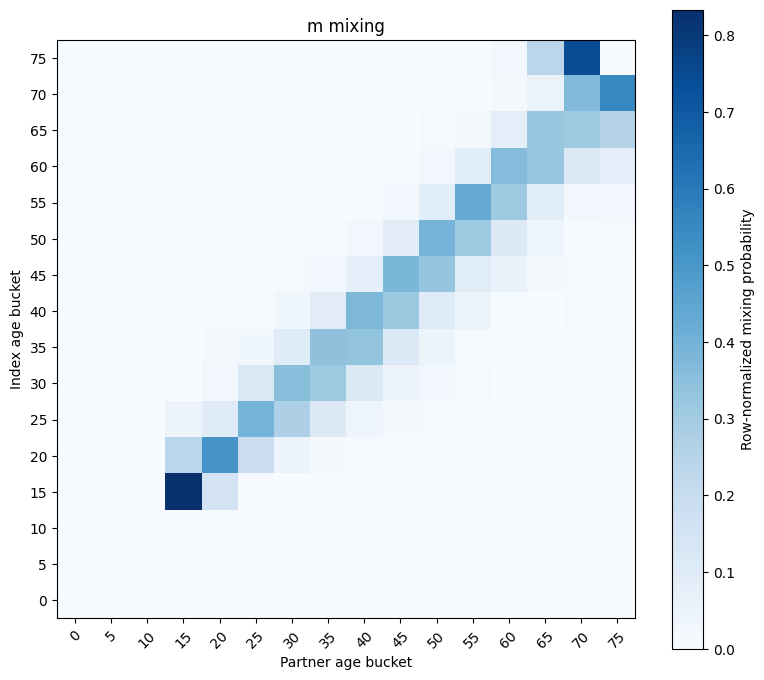

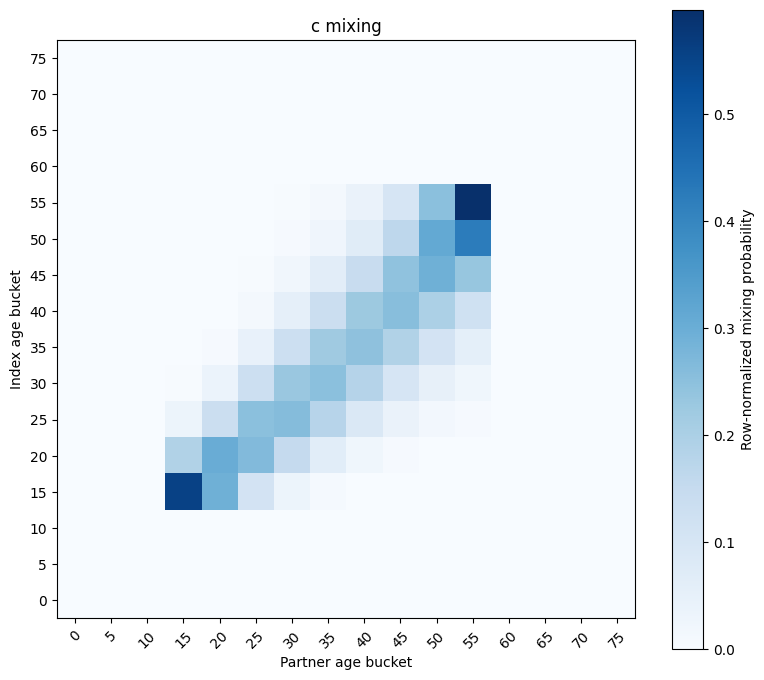

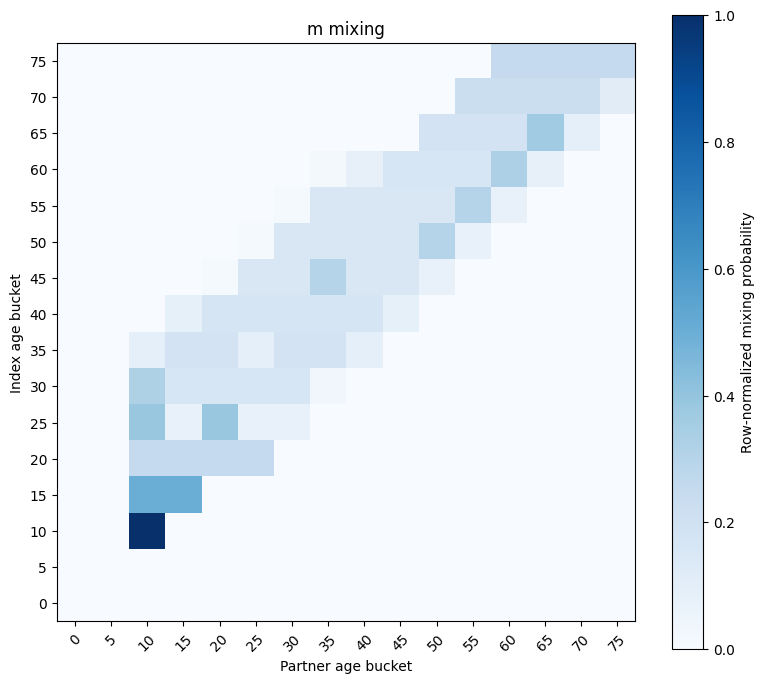

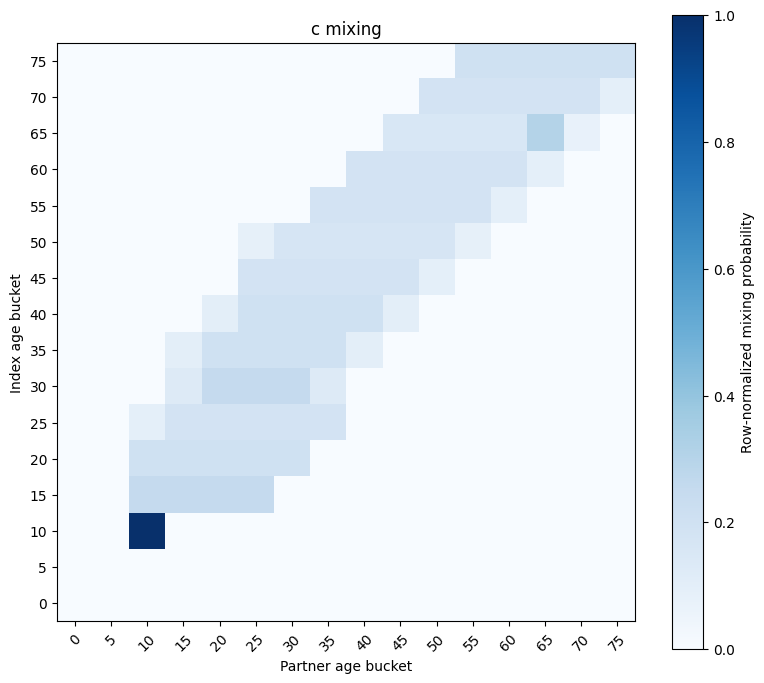

In [4]:
plot_mixing_matrices(standard_sim)
plot_mixing_matrices(no_mm_sim)

In [5]:
def update_contact_dict_maker(t_start=0):
    contact_dict = dict()
    #Define the intervention to be passed to the sim: will activate only after a burnin time t_start 
    #TODO: maybe also only do a particular predefined set of pids?
    def update_contact_dict(sim):
        if sim.t >= t_start:
            for layer_name, layer in sim.people.contacts.items():
                #get endpoints of each partnership/edge as a a list of indices
                fs = np.asarray(layer['f'], dtype=int)
                ms = np.asarray(layer['m'], dtype=int)

                assert fs.shape == ms.shape
                
                for i in range(fs.shape[0]):
                    if fs[i] not in contact_dict.keys():
                        contact_dict[fs[i]] = set()
                    if ms[i] not in contact_dict.keys():
                        contact_dict[ms[i]] = set()
                    contact_dict[fs[i]].add(ms[i])
                    contact_dict[ms[i]].add(fs[i])
    update_contact_dict.label='update_contact_dict'
    return contact_dict, update_contact_dict

def deg_dist_from_contact_dict(contact_dict):
    n=len(contact_dict.keys())
    
    degree_counts = dict() #maps degree of a node to the number of nodes with that degree
    for pid in contact_dict.keys():
        deg = len(contact_dict[pid])
        if deg not in degree_counts.keys():
            degree_counts[deg] = 0
        degree_counts[deg] += 1

    #Turn to a normalised numpy array
    max_count = max(degree_counts.keys())
    deg_dist = np.zeros(max_count) #we are only considering the degree distribution amongst those with contacts, so everything is shifted left by 1 in the indices
    for deg in degree_counts.keys():
        deg_dist[deg-1] = degree_counts[deg] / n

    return deg_dist

def degree_dist_dist(sim_pars, n_runs, rand_seed):
    records = []

    for run in range(n_runs):
        print(f"Running sim {run+1}/{n_runs}")
        
        temp_sim_pars = deepcopy(sim_pars)
        temp_sim_pars['rand_seed'] = rand_seed + run
        contact_dict, update_contact_dict = update_contact_dict_maker()
        temp_sim_pars['interventions'] = update_contact_dict
        temp_sim = hpv.Sim(temp_sim_pars)

        temp_sim.run()
        deg_dist = deg_dist_from_contact_dict(contact_dict)

        records.append(deg_dist)

    #Align lengths of all degree distributions
    max_record_length = 0 #meaning a degree of 1
    for record in records:
        max_record_length = len(record) if len(record)>max_record_length else max_record_length
    for i in range(len(records)):
        if len(records[i]) < max_record_length:
            new_record = np.zeros(max_record_length)
            for j in range(len(records[i])):
                new_record[j] = records[i][j]
            records[i] = new_record

    return records
    

In [6]:
standard_degree_dists = degree_dist_dist(base_pars, n_runs=20, rand_seed=0)

Running sim 1/20
Loading location-specific demographic data for "united kingdom"
Loading location-specific data for "united kingdom"
Sim(<no label>; 1980 to 2055; pop: 200000 default; epi: 8.23996e+08⚙, 727192♋︎)
Running sim 2/20
Loading location-specific demographic data for "united kingdom"
Loading location-specific data for "united kingdom"
Sim(<no label>; 1980 to 2055; pop: 200000 default; epi: 8.00298e+08⚙, 708151♋︎)
Running sim 3/20
Loading location-specific demographic data for "united kingdom"
Loading location-specific data for "united kingdom"
Sim(<no label>; 1980 to 2055; pop: 200000 default; epi: 7.96931e+08⚙, 721314♋︎)
Running sim 4/20
Loading location-specific demographic data for "united kingdom"
Loading location-specific data for "united kingdom"
Sim(<no label>; 1980 to 2055; pop: 200000 default; epi: 7.93251e+08⚙, 704720♋︎)
Running sim 5/20
Loading location-specific demographic data for "united kingdom"
Loading location-specific data for "united kingdom"
Sim(<no label>;

In [41]:
no_mm_degree_dists = degree_dist_dist(base_pars_no_matrix, n_runs=20, rand_seed = 0)

Running sim 1/20
Loading location-specific demographic data for "united kingdom"
Loading location-specific data for "united kingdom"
Sim(<no label>; 1980 to 2055; pop: 200000 default; epi: 2.05533e+08⚙, 230744♋︎)
Running sim 2/20
Loading location-specific demographic data for "united kingdom"
Loading location-specific data for "united kingdom"
Sim(<no label>; 1980 to 2055; pop: 200000 default; epi: 1.96089e+08⚙, 220309♋︎)
Running sim 3/20
Loading location-specific demographic data for "united kingdom"
Loading location-specific data for "united kingdom"
Sim(<no label>; 1980 to 2055; pop: 200000 default; epi: 2.1379e+08⚙, 236003♋︎)
Running sim 4/20
Loading location-specific demographic data for "united kingdom"
Loading location-specific data for "united kingdom"
Sim(<no label>; 1980 to 2055; pop: 200000 default; epi: 2.03199e+08⚙, 225034♋︎)
Running sim 5/20
Loading location-specific demographic data for "united kingdom"
Loading location-specific data for "united kingdom"
Sim(<no label>; 

In [ ]:
for record in standard_degree_dists:
    plt.plot(record)
plt.yscale('log')
plt.show()

In [ ]:
for record in no_mm_degree_dists:
    plt.plot(record)
plt.yscale('log')
plt.show()

In [224]:
def plot_degree_dist(x, capcolor):
    x = np.array(x)

    n = x.shape[1]
    
    mean = x.mean(0)
    std = x.std(0)
    degree = np.arange(1, n + 1)

    plt.bar(degree, mean, yerr=std, capsize=2, alpha=0,
            error_kw={
        "ecolor": capcolor,
        "capthick": 1
    })
    plt.xlabel("Degree")
    plt.ylabel("Fraction of nodes")

    #ticks = np.r_[np.arange(10, n, 10), n]
    #labels = [*map(str, ticks[:-1]), f"{n}"]
    ticks = np.r_[np.arange(10, n, 10)]
    labels = [*map(str, ticks[:])]
    plt.xticks([1]+list(ticks), [1]+labels)
    
    plt.yscale("log")
    plt.tight_layout()

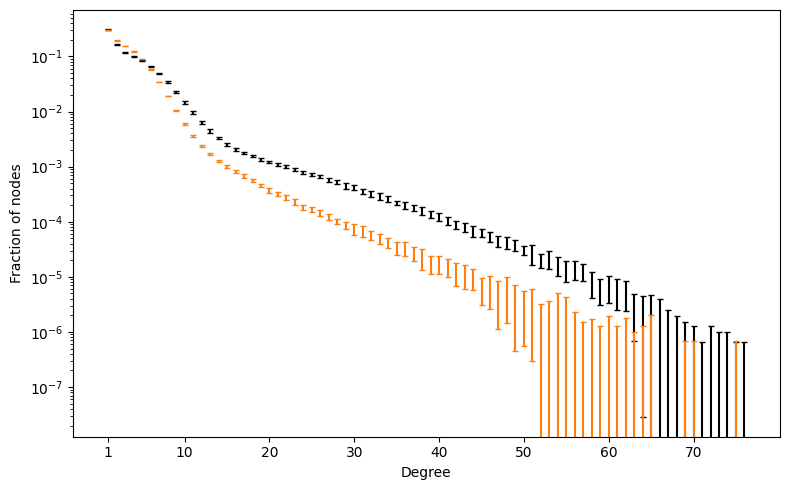

In [225]:
plt.figure(figsize=(8, 5))

plot_degree_dist(standard_degree_dists, 'black')
plot_degree_dist(no_mm_degree_dists, capcolor='tab:orange')

plt.show()

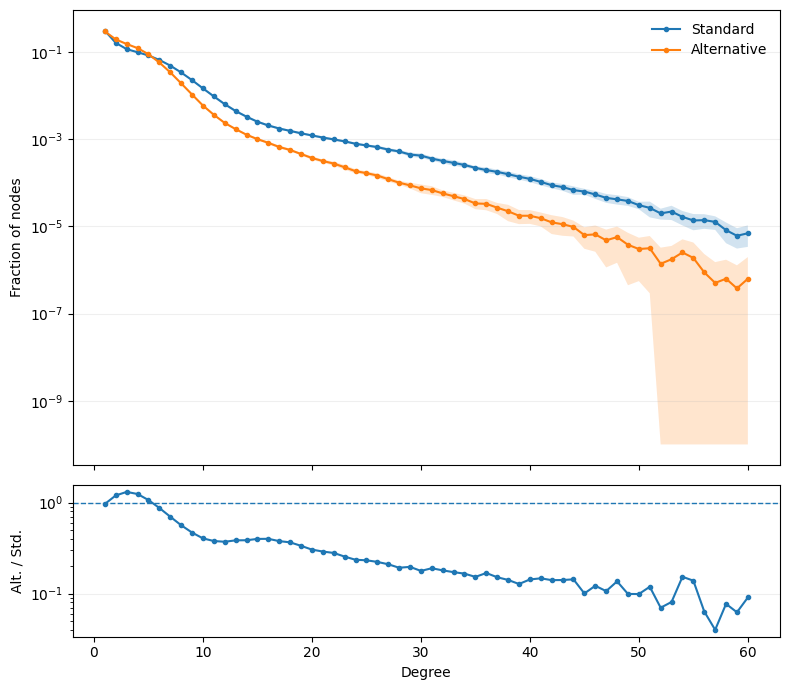

In [108]:
import numpy as np
import matplotlib.pyplot as plt


def get_degree_dist(trials, max_degree=60):
    n = max(map(len, trials))
    x = np.array([np.pad(t, (0, n-len(t))) for t in trials])

    mean = x.mean(0)[:max_degree]
    std  = x.std(0)[:max_degree]

    return mean, std


std_mean, std_sd = get_degree_dist(standard_degree_dists)
alt_mean, alt_sd = get_degree_dist(no_mm_degree_dists)

degree = np.arange(1, len(std_mean) + 1)

fig, (ax, axr) = plt.subplots(
    2, 1,
    figsize=(8, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# --- Degree distributions ---
for mean, sd, label in [
    (std_mean, std_sd, "Standard"),
    (alt_mean, alt_sd, "Alternative")
]:
    ax.plot(degree, mean, marker="o", ms=3, lw=1.5, label=label)
    ax.fill_between(
        degree,
        np.maximum(mean - sd, 1e-10),
        mean + sd,
        alpha=.2
    )

ax.set_yscale("log")
ax.set_ylabel("Fraction of nodes")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=.2)


# --- Ratio ---
ratio = alt_mean / std_mean

axr.plot(degree, ratio, marker="o", ms=3)
axr.axhline(1, ls="--", lw=1)

axr.set_xlabel("Degree")
axr.set_ylabel("Alt. / Std.")
axr.set_xticks(np.arange(0, 61, 10))
axr.grid(axis="y", alpha=.2)
plt.yscale('log')
plt.tight_layout()
plt.show()

In [25]:
import hpvsim as hpv
import numpy as np


class CancerTrajectoryTracker(hpv.Intervention):

    def __init__(self):
        super().__init__()

        # Previous states, keyed by UID
        self.prev_inf = {}
        self.prev_cin = {}
        self.prev_cancer = {}

        # Infection episode currently/latest associated with (uid, genotype)
        self.episode = {}

        # First events per person
        self.first_inf = {}
        self.first_cin = {}

        # One row per person developing cancer
        self.first_hpv = []
        self.cancer_hpv = []
        self.first_cin_out = []
        self.first_cancer = []

        self.seen_cancer = set()


    def apply(self, sim):

        p = sim.people
        dt = sim['dt']

        for i, uid in enumerate(p.uid):

            uid = int(uid)

            inf = p.infectious[:, i].copy()
            cin = p.cin[:, i].copy()
            cancer = p.cancerous[:, i].copy()

            old_inf = self.prev_inf.get(
                uid, np.zeros_like(inf, dtype=bool)
            )
            old_cin = self.prev_cin.get(
                uid, np.zeros_like(cin, dtype=bool)
            )
            old_cancer = self.prev_cancer.get(
                uid, np.zeros_like(cancer, dtype=bool)
            )

            # ==========================================
            # NEW INFECTION EPISODES
            # ==========================================

            for g in np.where(inf & ~old_inf)[0]:

                infection_t = p.date_infectious[g, i]

                if not np.isfinite(infection_t):
                    continue

                # Was this a reactivation rather than new acquisition?
                reactivation_t = p.date_reactivated[g, i]

                is_reactivation = (
                    np.isfinite(reactivation_t)
                    and np.isclose(reactivation_t, infection_t)
                )

                if not is_reactivation:

                    # Exact age when infection occurred
                    infection_age = (
                        float(p.age[i])
                        - (sim.t - infection_t) * dt
                    )

                    # New episode replaces previous episode
                    # for this UID/genotype
                    self.episode[(uid, int(g))] = infection_age

                    # First-ever observed HPV acquisition
                    if uid not in self.first_inf:
                        self.first_inf[uid] = infection_age

                # For reactivation, deliberately DO NOT overwrite
                # episode[(uid,g)]. We retain the original acquisition.

            # ==========================================
            # FIRST CIN
            # ==========================================

            new_cin = cin & ~old_cin

            if new_cin.any() and uid not in self.first_cin:

                # Reconstruct exact age from date_cin
                cin_dates = p.date_cin[new_cin, i]

                valid = cin_dates[np.isfinite(cin_dates)]

                if len(valid):
                    cin_t = valid.min()

                    self.first_cin[uid] = (
                        float(p.age[i])
                        - (sim.t - cin_t) * dt
                    )

            # ==========================================
            # FIRST CANCER
            # ==========================================

            new_cancer = cancer & ~old_cancer

            if new_cancer.any() and uid not in self.seen_cancer:

                # If >1 genotype happens simultaneously, take earliest
                gs = np.where(new_cancer)[0]

                cancer_dates = p.date_cancerous[gs, i]
                valid = np.isfinite(cancer_dates)

                if valid.any():

                    gs = gs[valid]
                    cancer_dates = cancer_dates[valid]

                    g = int(gs[np.argmin(cancer_dates)])
                    cancer_t = np.min(cancer_dates)

                    cancer_age = (
                        float(p.age[i])
                        - (sim.t - cancer_t) * dt
                    )

                    self.seen_cancer.add(uid)

                    # First HPV acquisition of any genotype
                    self.first_hpv.append(
                        self.first_inf.get(uid, np.nan)
                    )

                    # Acquisition episode associated with
                    # cancer-causing genotype
                    self.cancer_hpv.append(
                        self.episode.get((uid, g), np.nan)
                    )

                    # First CIN of any genotype
                    self.first_cin_out.append(
                        self.first_cin.get(uid, np.nan)
                    )

                    self.first_cancer.append(cancer_age)

            # ==========================================
            # SAVE STATE
            # ==========================================

            self.prev_inf[uid] = inf
            self.prev_cin[uid] = cin
            self.prev_cancer[uid] = cancer


    def get_results(self):

        # IMPORTANT: don't remove NaNs here.
        # Keeping arrays aligned means row i always represents
        # the same cancer case across all four arrays.

        return (
            np.asarray(self.first_hpv),
            np.asarray(self.cancer_hpv),
            np.asarray(self.first_cin_out),
            np.asarray(self.first_cancer),
        )

In [26]:
base_pars['verbose'] = 1
smaller_base_pars = deepcopy(base_pars)
smaller_base_pars['n_agents'] = 10_000
tracked_standard_sim = hpv.Sim(smaller_base_pars)
tracker = CancerTrajectoryTracker()
tracker.initialize(tracked_standard_sim)
tracked_standard_sim['interventions'].append(tracker)

base_pars_no_matrix['verbose'] = 1
smaller_base_pars_nm = deepcopy(base_pars_no_matrix)
smaller_base_pars_nm['n_agents'] = 10_000
tracked_nm_sim = hpv.Sim(smaller_base_pars_nm)
tracker = CancerTrajectoryTracker()
tracker.initialize(tracked_nm_sim)
tracked_nm_sim['interventions'].append(tracker)

Loading location-specific demographic data for "united kingdom"
Loading location-specific demographic data for "united kingdom"


In [27]:
tracked_standard_sim.run()
tracked_nm_sim.run()

Initializing sim with 10000 agents
Loading location-specific data for "united kingdom"
  Running 1980.0 ( 0/304) (0.04 s)  ———————————————————— 0%
  Running 1980.2 ( 1/304) (0.12 s)  ———————————————————— 1%
  Running 1980.5 ( 2/304) (0.17 s)  ———————————————————— 1%
  Running 1980.8 ( 3/304) (0.23 s)  ———————————————————— 1%
  Running 1981.0 ( 4/304) (0.29 s)  ———————————————————— 2%
  Running 1981.2 ( 5/304) (0.35 s)  ———————————————————— 2%
  Running 1981.5 ( 6/304) (0.41 s)  ———————————————————— 2%
  Running 1981.8 ( 7/304) (0.47 s)  ———————————————————— 3%
  Running 1982.0 ( 8/304) (0.53 s)  ———————————————————— 3%
  Running 1982.2 ( 9/304) (0.60 s)  ———————————————————— 3%
  Running 1982.5 (10/304) (0.66 s)  ———————————————————— 4%
  Running 1982.8 (11/304) (0.71 s)  ———————————————————— 4%
  Running 1983.0 (12/304) (0.78 s)  ———————————————————— 4%
  Running 1983.2 (13/304) (0.84 s)  ———————————————————— 5%
  Running 1983.5 (14/304) (0.90 s)  ———————————————————— 5%
  Running 198

Sim(<no label>; 1980 to 2055; pop: 10000 default; epi: 1.6824e+08⚙, 199693♋︎)

In [28]:
standard_first_hpv, standard_cancer_hpv, standard_first_cin, standard_first_cancer = [
    x for x in tracked_standard_sim['interventions']
    if isinstance(x, CancerTrajectoryTracker)
    ][0].get_results()
standard_data = [standard_first_hpv, standard_cancer_hpv, standard_first_cin, standard_first_cancer]

In [29]:
nm_first_hpv, nm_cancer_hpv, nm_first_cin, nm_first_cancer = [
    x for x in tracked_nm_sim['interventions']
    if isinstance(x, CancerTrajectoryTracker)
    ][0].get_results()
nm_data = [nm_first_hpv, nm_cancer_hpv, nm_first_cin, nm_first_cancer]

In [37]:
np.percentile(standard_first_cancer, [25,50,75])

array([38.25, 47.  , 58.75])

In [36]:
np.percentile(nm_first_cancer, [25,50,75])

array([45.8125, 56.25  , 66.4375])

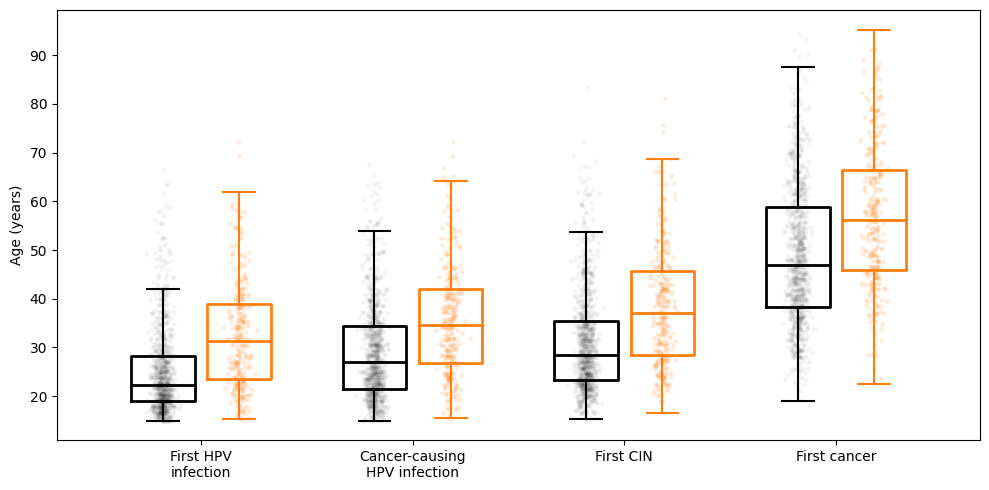

In [30]:
labels = [
    "First HPV\ninfection",
    "Cancer-causing\nHPV infection",
    "First CIN",
    "First cancer"
]

fig, ax = plt.subplots(figsize=(10, 5))

pos = np.arange(len(labels))
offset = 0.18

for data, positions, color in [
    (standard_data,    pos - offset, 'black'),
    (nm_data, pos + offset, "tab:orange")
]:
    clean = [x[np.isfinite(x)] for x in data]

    # Draw each box separately so it gets its event colour
    for x, p, in zip(clean, positions):

        ax.boxplot(
            [x],
            positions=[p],
            widths=0.3,
            showfliers=False,
            boxprops=dict(color=color, linewidth=2),
            whiskerprops=dict(color=color, linewidth=1.5),
            capprops=dict(color=color,  linewidth=1.5),
            medianprops=dict(color=color, linewidth=2),
        )
        
    # Dots colored by event type
    for x, p in zip(clean, positions):
        jitter = np.random.normal(p, 0.025, len(x))
        ax.scatter(
            jitter, x,
            s=6,
            alpha=0.03 if color=='black' else 0.1,
            color=color
        )



ax.set_xticks(pos)
ax.set_xticklabels(labels)
ax.set_ylabel("Age (years)")

plt.tight_layout()
plt.show()


Standard quartiles: [ 9.5  14.25 19.5 ]
Alternate quartiles: [12.5625 18.5    26.9375]


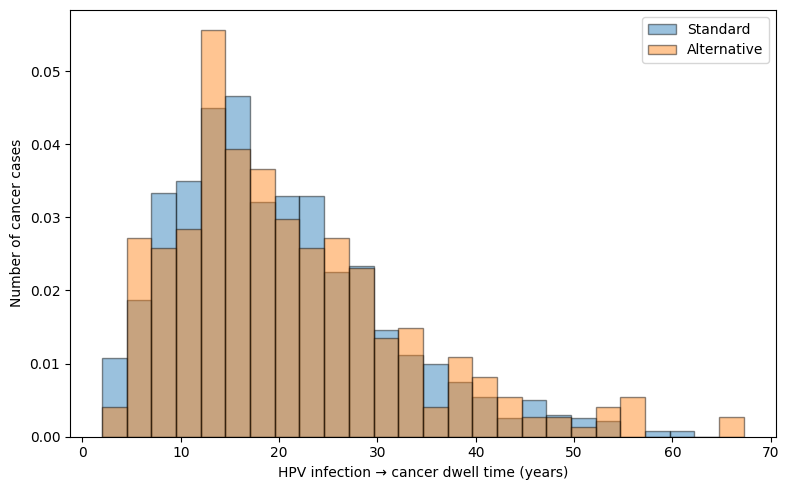

In [162]:

dwell_standard = standard_first_cancer - standard_cancer_hpv
dwell_alternative = nm_first_cancer - nm_cancer_hpv

dwell_standard = dwell_standard[np.isfinite(dwell_standard)]
dwell_alternative = dwell_alternative[np.isfinite(dwell_alternative)]

print(f"Standard quartiles: {np.percentile(dwell_time, [25, 50, 75])}")
print(f"Alternate quartiles: {np.percentile(dwell_alternative, [25, 50, 75])}")

# Shared bins
bins = np.histogram_bin_edges(
    np.concatenate([dwell_standard, dwell_alternative]),
    bins="auto"
)

plt.figure(figsize=(8, 5))

plt.hist(
    dwell_standard,
    bins=bins,
    alpha=0.45,
    label="Standard",
    edgecolor="black",
    density=True,
)

plt.hist(
    dwell_alternative,
    bins=bins,
    alpha=0.45,
    label="Alternative",
    edgecolor="black",
    density=True,
)

plt.xlabel("HPV infection → cancer dwell time (years)")
plt.ylabel("Number of cancer cases")
plt.legend()

plt.tight_layout()
plt.show()

In [3]:
def run_repeats(sim, n=20):
    trajectories = []

    for seed in range(n):
        print(f"Run {seed + 1}/{n}")

        s = deepcopy(sim)
        s['rand_seed'] = seed
        s.run()

        trajectories.append(
            np.asarray(deepcopy(s.results['cancer_incidence'].values))
        )

    return np.array(trajectories)


# Run both scenarios
inc1 = run_repeats(standard_sim, 20)
inc2 = run_repeats(no_mm_sim, 20)

Run 1/20
Loading location-specific data for "united kingdom"
Sim(<no label>; 1980 to 2055; pop: 200000 default; epi: 8.23996e+08⚙, 727192♋︎)
Run 2/20
Loading location-specific data for "united kingdom"
Sim(<no label>; 1980 to 2055; pop: 200000 default; epi: 8.00298e+08⚙, 708151♋︎)
Run 3/20
Loading location-specific data for "united kingdom"
Sim(<no label>; 1980 to 2055; pop: 200000 default; epi: 7.96931e+08⚙, 721314♋︎)
Run 4/20
Loading location-specific data for "united kingdom"
Sim(<no label>; 1980 to 2055; pop: 200000 default; epi: 7.93251e+08⚙, 704720♋︎)
Run 5/20
Loading location-specific data for "united kingdom"
Sim(<no label>; 1980 to 2055; pop: 200000 default; epi: 7.85291e+08⚙, 682135♋︎)
Run 6/20
Loading location-specific data for "united kingdom"
Sim(<no label>; 1980 to 2055; pop: 200000 default; epi: 8.23003e+08⚙, 737233♋︎)
Run 7/20
Loading location-specific data for "united kingdom"
Sim(<no label>; 1980 to 2055; pop: 200000 default; epi: 8.05273e+08⚙, 718839♋︎)
Run 8/20
Load

In [10]:
def quartiles(x):
    return np.percentile(x, [25, 50, 75], axis=0)

lq1, med1, uq1 = quartiles(inc1)
lq2, med2, uq2 = quartiles(inc2)

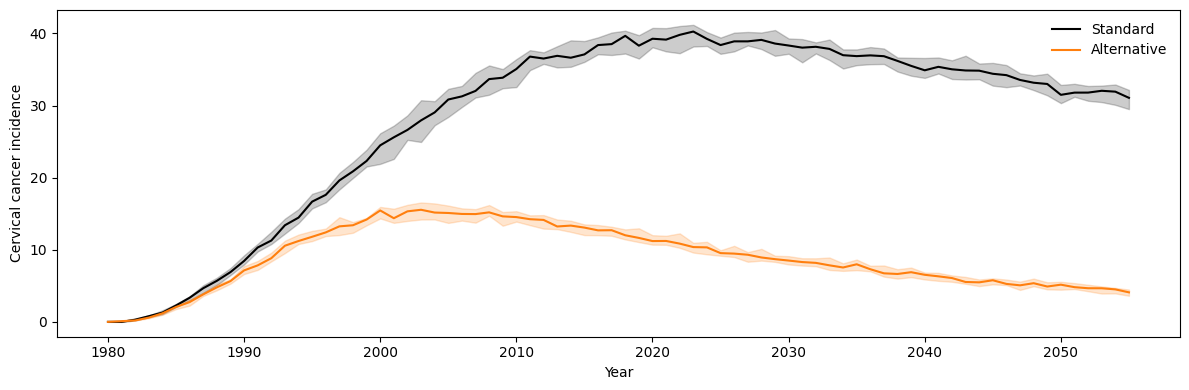

In [22]:
years = np.arange(1980,2056,1)

fig, ax = plt.subplots(figsize=(12, 4))

# Sim 1
ax.plot(years, med1, label="Standard", color='black')
ax.fill_between(years, lq1, uq1, alpha=0.2, color='black')

# Sim 2
ax.plot(years, med2, label="Alternative", color='tab:orange')
ax.fill_between(years, lq2, uq2, alpha=0.2, color='tab:orange')

ax.set_xlabel("Year")
ax.set_ylabel("Cervical cancer incidence")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [171]:

class HPVPrevalenceTracker(hpv.Intervention):

    def __init__(self):
        super().__init__()
        self.prevalence = []
        self.time = []

    def apply(self, sim):
        p = sim.people

        # Infected with >=1 HPV genotype
        infected = p.infectious.any(axis=0)

        # Restrict denominator to alive women of interest
        alive = (
            p.alive
            & p.is_female
            & (p.age >= 15)
            & (p.age < 65)
        )

        self.prevalence.append(
            infected[alive].mean()
        )

        self.time.append(
            sim['start'] + sim.t * sim['dt']
        )

    def get_results(self):
        return (
            np.asarray(self.time),
            np.asarray(self.prevalence)
        )

In [182]:
from InterventionAlgorithms.NHS_Vacc import vaccinations
from InterventionAlgorithms.screeningAlgorithms import get_interventions

In [187]:
tracker = HPVPrevalenceTracker()

sim = hpv.Sim(
    base_pars,
    #base_pars_no_matrix,
    interventions=[tracker]+ vaccinations + get_interventions(5,5,5)
)

sim.run()

Loading location-specific demographic data for "united kingdom"
Initializing sim with 200000 agents
Loading location-specific data for "united kingdom"


/Users/fabian/Documents/DPhil Work/Academic Work/EnglandCervicalScreeningProject/hpvsim/interventions.py:364: RuntimeWarning: invalid value encountered in power
  if self.annual_prob: self.prob = 1-(1-self.prob)**sim['dt']


  Running 1980.0 ( 0/304) (0.16 s)  ———————————————————— 0%
  Running 1980.2 ( 1/304) (0.30 s)  ———————————————————— 1%
  Running 1980.5 ( 2/304) (0.39 s)  ———————————————————— 1%
  Running 1980.8 ( 3/304) (0.47 s)  ———————————————————— 1%
  Running 1981.0 ( 4/304) (0.63 s)  ———————————————————— 2%
  Running 1981.2 ( 5/304) (0.75 s)  ———————————————————— 2%
  Running 1981.5 ( 6/304) (0.84 s)  ———————————————————— 2%
  Running 1981.8 ( 7/304) (0.93 s)  ———————————————————— 3%
  Running 1982.0 ( 8/304) (1.09 s)  ———————————————————— 3%
  Running 1982.2 ( 9/304) (1.22 s)  ———————————————————— 3%
  Running 1982.5 (10/304) (1.31 s)  ———————————————————— 4%
  Running 1982.8 (11/304) (1.40 s)  ———————————————————— 4%
  Running 1983.0 (12/304) (1.57 s)  ———————————————————— 4%
  Running 1983.2 (13/304) (1.70 s)  ———————————————————— 5%
  Running 1983.5 (14/304) (1.79 s)  ———————————————————— 5%
  Running 1983.8 (15/304) (1.88 s)  •——————————————————— 5%
  Running 1984.0 (16/304) (2.05 s)  •———

Sim(<no label>; 1980 to 2055; pop: 200000 default; epi: 5.68292e+08⚙, 77739.7♋︎)

In [188]:
tracker = next(
    x for x in sim['interventions']
    if isinstance(x, HPVPrevalenceTracker)
)

time, hpv_prevalence = tracker.get_results()

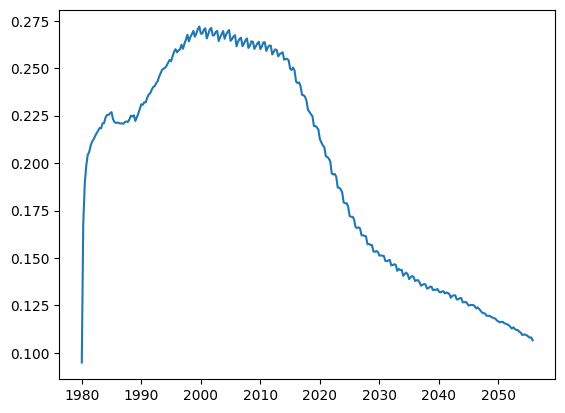

In [189]:
plt.plot(time, hpv_prevalence) #new matrix, interventions

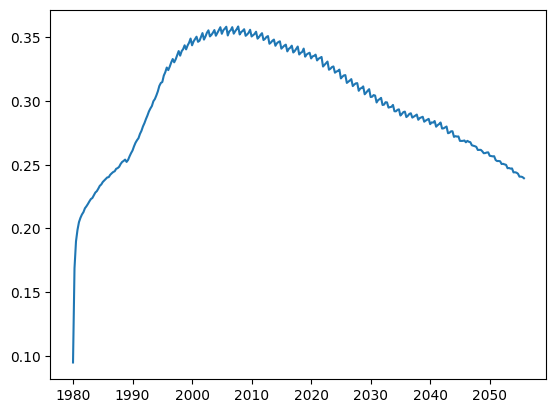

In [175]:
plt.plot(time, hpv_prevalence) #new matrix

In [99]:
from InterventionAlgorithms.NHS_Vacc import vaccinations
import numpy as np

class HPVPrevalenceTracker(hpv.Intervention): #tracks HPV infection (infectiousness) prevalence amongst female agents, slicing the data in many customisable ways

    def __init__(self, snapshot_years=None, age_bins=None, 
                 vacc_pop_only = False, unvacc_pop_only = False, #for restricting the tracked population by vaccination status
                 min_age = None, max_age = None, #for restricting the tracked population by age. Brackets are inclusive on both sides
                 ):
        super().__init__()

        self.time = []

        self.prevalence_any = []
        self.prevalence_16 = []
        self.prevalence_18 = []
        self.prevalence_1618 = []
        self.prevalence_hi5 = []
        self.prevalence_ohr = []

        self.snapshot_years = snapshot_years or []
        self.age_bins = np.asarray(
            age_bins if age_bins is not None else np.arange(0, 101, 5)
        )

        self.snapshots_any = {}
        self.snapshots_16 = {}
        self.snapshots_18 = {}
        self.snapshots_1618 = {}
        self.snapshots_hi5 = {}
        self.snapshots_ohr = {}

        assert not (vacc_pop_only and unvacc_pop_only)
        self.vacc_pop_only = vacc_pop_only
        self.unvacc_pop_only = unvacc_pop_only

        assert (min_age is None and max_age is None) or ((min_age is not None and max_age is not None) and max_age>=min_age)
        self.ages_matter = min_age is not None #previous assertion ensures this is correct
        self.min_age = min_age
        self.max_age = max_age


    def apply(self, sim):
        p = sim.people

        infected_any = p.infectious.any(axis=0) 
        infected_16 = p.infectious[0]
        infected_18 = p.infectious[1]
        infected_1618 = np.logical_or(p.infectious[0] , p.infectious[1])
        infected_hi5 = p.infectious[2]
        infected_ohr = p.infectious[3]

        #alive = p.alive
        alive = (p.alive & (p.sex == 0))
        if self.vacc_pop_only: #restrict focus to vaccinated individuals if we want to do that
            alive = np.logical_and(alive, p.vaccinated)
        elif self.unvacc_pop_only: #restrict focus to unvaccinated individuals if we want to do that
            alive = np.logical_and(alive , np.logical_not(p.vaccinated))
        if self.ages_matter:
            alive = (alive & (p.age>=self.min_age) & (p.age <= self.max_age))
        #We only focus on those with normal cytologies
        #abnormal_cells_any = np.logical_or(p.cin.any(axis=0), p.cancerous.any(axis=0))
        #alive = (alive & (~ abnormal_cells_any))


        year = sim['start'] + sim.t * sim['dt']
        self.time.append(year)

        #print(sim.t)
        #print(alive)

        if alive.any():
            # Overall prevalence
            self.prevalence_any.append(np.average(infected_any[alive], weights=p.scale[alive])) 
            self.prevalence_16.append(np.average(infected_16[alive], weights=p.scale[alive])) 
            self.prevalence_18.append(np.average(infected_18[alive], weights=p.scale[alive]))
            self.prevalence_1618.append(np.average(infected_1618[alive], weights=p.scale[alive]))
            self.prevalence_hi5.append(np.average(infected_hi5[alive], weights=p.scale[alive]))
            self.prevalence_ohr.append(np.average(infected_ohr[alive], weights=p.scale[alive]))

            # Snapshot if this is nearest timestep to requested year
            for snapshot_year in self.snapshot_years:
                snapshot_t = round((snapshot_year - sim['start']) / sim['dt'])
    
                if sim.t == snapshot_t:
                    for snapshots, infected in [(self.snapshots_any,infected_any),
                                                (self.snapshots_16,infected_16),
                                                (self.snapshots_18,infected_18),
                                                (self.snapshots_1618,infected_1618),
                                                (self.snapshots_hi5,infected_hi5),
                                                (self.snapshots_ohr,infected_ohr),
                                                ]:
                        prev = []
    
                        for lo, hi in zip(
                            self.age_bins[:-1],
                            self.age_bins[1:]
                        ):
                            group = (
                                alive
                                & (p.age >= lo)
                                & (p.age < hi)
                            )
    
                            prev.append(
                                np.average(infected[group], weights=p.scale[group])
                                if group.any()
                                else np.nan
                            )
    
                        snapshots[snapshot_year] = np.asarray(prev)
        else:
            self.prevalence_any.append(np.nan)
            self.prevalence_16.append(np.nan)
            self.prevalence_18.append(np.nan)
            self.prevalence_1618.append(np.nan)
            self.prevalence_hi5.append(np.nan)
            self.prevalence_ohr.append(np.nan)

            for snapshot_year in self.snapshot_years:
                snapshot_t = round((snapshot_year - sim['start']) / sim['dt'])
    
                if sim.t == snapshot_t:
                    for snapshots, infected in [(self.snapshots_any,infected_any),
                                                (self.snapshots_16,infected_16),
                                                (self.snapshots_18,infected_18),
                                                (self.snapshots_1618,infected_1618),
                                                (self.snapshots_hi5,infected_hi5),
                                                (self.snapshots_ohr,infected_ohr),
                                                ]:
                        prev = []
    
                        for lo, hi in zip(
                            self.age_bins[:-1],
                            self.age_bins[1:]
                        ):
                            group = (
                                alive
                                & (p.age >= lo)
                                & (p.age < hi)
                            )
    
                            prev.append(
                                np.nan
                            )
    
                        snapshots[snapshot_year] = np.asarray(prev)


        



    def get_results(self):
        return (
            np.asarray(self.time),
            np.asarray(self.prevalence_any),
            np.asarray(self.prevalence_16),
            np.asarray(self.prevalence_18),
            np.asarray(self.prevalence_1618),
            np.asarray(self.prevalence_hi5),
            np.asarray(self.prevalence_ohr),
            self.snapshots_any,
            self.snapshots_16,
            self.snapshots_18,
            self.snapshots_1618,
            self.snapshots_hi5,
            self.snapshots_ohr

        )




In [107]:
import sciris as sc

In [101]:
%pwd

'/Users/fabian/Documents/DPhil Work/Academic Work/EnglandCervicalScreeningProject/project_modelling'

In [108]:
%cd "/Users/fabian/Documents/DPhil Work/Academic Work/EnglandCervicalScreeningProject"

/Users/fabian/Documents/DPhil Work/Academic Work/EnglandCervicalScreeningProject


In [111]:
import pickle
import project_modelling.scenario_configuration as scenario_configuration


#Load in properties of this round of result-generation from scenario_parameterisation.py
seeds = scenario_configuration.seeds
alg_name = scenario_configuration.alg_name
pars = scenario_configuration.adapted_pars
cal_filename = scenario_configuration.cal_filename


#Load in calibrated parameter sets
print(f"Loading calibrated parameters from {cal_filename}")
with open(cal_filename, 'rb') as file:
    loadeddata = pickle.load(file)
final_cal_data = loadeddata['final_cal_data'] #this is a list of parameter-tuples, so has a fixed ordering
par_labels = loadeddata['par_labels']

Loading calibrated parameters from project_modelling/calibration_results/FinalPooledCalibration_8_68_76_55_55_9_9__96_7_13.pickle


In [ ]:
print("RUNNING THIS CELL FILTERS DOWN OUR PARAMETER SET BY FILTERING ON CCI")
#below: from acceptance on CCI, which combos of (seed, par) are good, by epsilon=0.15
#accepted_seed_par = {(1, 31), (0, 5), (2, 2), (0, 14), (2, 11), (0, 23), (1, 15), (1, 24), (1, 33), (2, 32), (1, 42), (0, 7), (2, 4), (0, 16), (1, 8), (1, 26), (2, 25), (1, 35), (0, 37), (2, 43), (0, 0), (1, 10), (1, 19), (1, 28), (0, 30), (2, 27), (1, 37), (0, 39), (2, 36), (0, 2), (1, 3), (1, 12), (2, 20), (1, 30), (0, 32), (2, 29), (1, 39), (2, 38), (1, 5), (1, 14), (2, 13), (1, 23), (0, 25), (2, 22), (1, 32), (0, 34), (2, 31), (0, 43), (1, 7), (1, 16), (0, 18), (2, 15), (1, 25), (2, 24), (0, 36), (2, 33), (2, 42), (1, 0), (1, 9), (0, 11), (2, 8), (1, 18), (0, 20), (2, 17), (0, 29), (2, 26), (0, 38), (2, 35), (1, 2), (0, 4), (2, 1), (1, 11), (2, 10), (1, 20), (0, 22), (0, 31), (2, 28), (2, 37), (1, 4), (2, 3), (1, 13), (0, 15), (0, 24), (0, 33), (2, 30), (0, 42), (1, 34), (1, 43), (2, 5), (2, 14), (0, 26), (2, 23), (0, 35), (1, 27), (1, 36), (0, 10), (2, 7), (0, 19), (2, 16), (0, 28), (1, 38), (1, 1), (0, 3), (2, 0), (0, 12), (2, 18)}

#below: from acceptance on CCI, which combos of (seed, par) are good, by epsilon=0.1
#accepted_seed_par = {(1, 28), (0, 30), (0, 36), (2, 33), (1, 31), (1, 37), (0, 39), (2, 36), (1, 34), (1, 43), (0, 2), (2, 2), (1, 3), (0, 20), (0, 26), (1, 15), (2, 23), (2, 20), (0, 38), (2, 35), (1, 33), (0, 7), (2, 4), (2, 7), (2, 10), (1, 14), (0, 28), (0, 25), (2, 22), (2, 28), (2, 25), (1, 35), (0, 37), (0, 43), (1, 38), (0, 3), (2, 0), (2, 3), (1, 7), (0, 15), (1, 10), (2, 15), (1, 25), (0, 33)}

#between different seeds, HPV doesnt really change so just take the set of accepted par#TODO maybe weight by resampling by the number that are accpetd/not accepted?
accpeted_pars = set()
for _, par in accepted_seed_par:
    accpeted_pars.add(par)

rejected_pars = set(range(len(final_cal_data))) - accpeted_pars

#filter final cal data
for par_index in reversed(sorted(rejected_pars)):
    final_cal_data.pop(par_index)

In [112]:
%cd '/Users/fabian/Documents/DPhil Work/Academic Work/EnglandCervicalScreeningProject/project_modelling'

/Users/fabian/Documents/DPhil Work/Academic Work/EnglandCervicalScreeningProject/project_modelling


In [113]:
%pwd

'/Users/fabian/Documents/DPhil Work/Academic Work/EnglandCervicalScreeningProject/project_modelling'

In [114]:
#build up a set of alternative base_pars for setting up each sim that could come out of this calibration

base_parss = []

num_params = len(final_cal_data) #number of parameterisations which make up the ensemble model we are using
for i in range(num_params):
    cal_params = final_cal_data[i][0] #specific parametersation of this iteration (note final_cal_data[i] is a tuple (parameterisation tuple, GOF, order statistic of GOF within the calibration that generated it, ID of calibration where the parameterisation was sampled ))
    tmp_base_pars = deepcopy(base_pars) #make deep copy of provided {base_pars} to add specific calibration parameters and logger to it without changing the original copy passed into this function

    tmp_base_pars['n_agents'] = 5000 #TODO: remove this once I have got the code working as I want

    #Set non-genotype calibrated parameters to this iteration's parameterisation
    #tmp_base_pars['beta'] = 0.09 
    #tmp_base_pars['f_cross_layer'] = 0.07 
    #tmp_base_pars['m_cross_layer'] = 0.29 
    tmp_base_pars['beta'] = cal_params[par_labels.index('params_beta')]
    tmp_base_pars['f_cross_layer'] = cal_params[par_labels.index('params_f_cross_layer')]
    tmp_base_pars['m_cross_layer'] = cal_params[par_labels.index('params_m_cross_layer')]

    #Set up {tmp_base_pars} to allow for specification of genotype parameters
    tmp_base_pars['genotype_pars'] = sc.objdict() #initialise genotype parameters within hpvsim
    for g in tmp_base_pars['genotypes']:
        tmp_base_pars['genotype_pars'][g] = hpv.parameters.get_genotype_pars(genotype=g)

    #Set genotype calibrated parameters to this iteration's parameterisation
    tmp_base_pars['genotype_pars']['hpv16']['cin_fn']['k'] = cal_params[par_labels.index('params_hpv16_cin_fn_k')]
    tmp_base_pars['genotype_pars']['hpv16']['dur_cin']['par1'] = cal_params[par_labels.index('params_hpv16_dur_cin_par1')]

    tmp_base_pars['genotype_pars']['hpv18']['cin_fn']['k'] = cal_params[par_labels.index('params_hpv18_cin_fn_k')]
    tmp_base_pars['genotype_pars']['hpv18']['dur_cin']['par1'] = cal_params[par_labels.index('params_hpv18_dur_cin_par1')]
    
    tmp_base_pars['genotype_pars']['hi5']['cin_fn']['k'] = cal_params[par_labels.index('params_hi5_cin_fn_k')]
    tmp_base_pars['genotype_pars']['hi5']['dur_cin']['par1'] = cal_params[par_labels.index('params_hi5_dur_cin_par1')]
    tmp_base_pars['genotype_pars']['hi5']['rel_beta'] = cal_params[par_labels.index('params_hi5_rel_beta')]

    tmp_base_pars['genotype_pars']['ohr']['cin_fn']['k'] = cal_params[par_labels.index('params_ohr_cin_fn_k')]
    tmp_base_pars['genotype_pars']['ohr']['dur_cin']['par1'] = cal_params[par_labels.index('params_ohr_dur_cin_par1')]
    tmp_base_pars['genotype_pars']['ohr']['rel_beta'] = cal_params[par_labels.index('params_ohr_rel_beta')]

    base_parss.append(tmp_base_pars)

In [ ]:
import contextlib
import io

age1618_prevs_smoothed = []
age1921_prevs_smoothed = []
age2224_prevs_smoothed = []

age1618_hi5_prevs_smoothed = []
age1921_hi5_prevs_smoothed = []
age2224_hi5_prevs_smoothed = []

age1618_ohr_prevs_smoothed = []
age1921_ohr_prevs_smoothed = []
age2224_ohr_prevs_smoothed = []



for seed in range(6):
    for i in range(len(base_parss)):
        tracker = HPVPrevalenceTracker(
            snapshot_years=[2010, 2030, 2050],
            age_bins=np.arange(0, 101, 5)
        )
        tracker_vaccpop = HPVPrevalenceTracker(
            snapshot_years=[2010, 2030, 2050],
            age_bins=np.arange(0, 101, 5),
            vacc_pop_only=True
        )
        tracker_unvaccpop = HPVPrevalenceTracker(
            snapshot_years=[2010, 2030, 2050],
            age_bins=np.arange(0, 101, 5),
            unvacc_pop_only=True
        )
        tracker_16to18yo = HPVPrevalenceTracker(
            age_bins = np.arange(0,101,101), #nominal bins, doesnt matter here
            min_age=16,
            max_age=18
        )
        tracker_19to21yo = HPVPrevalenceTracker(
            age_bins = np.arange(0,101,101), #nominal bins, doesnt matter here
            min_age=19,
            max_age=21
        )
        tracker_22to24yo = HPVPrevalenceTracker(
            age_bins = np.arange(0,101,101), #nominal bins, doesnt matter here
            min_age=22,
            max_age=24

        )


        with contextlib.redirect_stdout(io.StringIO()):
            test_sim = hpv.Sim(base_parss[i], interventions=vaccinations + [tracker,
                                                                        tracker_vaccpop,tracker_unvaccpop, 
                                                                        tracker_16to18yo, tracker_19to21yo, tracker_22to24yo])
            test_sim['rand_seed'] = seed
            test_sim['n_agents'] = 5_000 #NOTE: I need a bigger n for other genotypes to be modelled properly
            test_sim['end'] = 2050


            print(test_sim['genotypes'])
            test_sim.run()

        ts =  [
            x for x in test_sim['interventions']
            if isinstance(x, HPVPrevalenceTracker)
        ]
        tracker = ts[0]
        tracker_vaccpop = ts[1]
        traker_unvaccpop = ts[2]
        tracker_16to18yo = ts[3]
        tracker_19to21yo = ts[4]
        tracker_22to24yo = ts[5]

        #assertions to check the trackers have been labelled correctly
        assert tracker_vaccpop.vacc_pop_only
        assert tracker_unvaccpop.unvacc_pop_only 
        assert tracker_16to18yo.ages_matter and tracker_16to18yo.min_age==16 and tracker_16to18yo.max_age==18
        assert tracker_19to21yo.ages_matter and tracker_19to21yo.min_age==19 and tracker_19to21yo.max_age==21
        assert tracker_22to24yo.ages_matter and tracker_22to24yo.min_age==22 and tracker_22to24yo.max_age==24


        from scipy.ndimage import uniform_filter1d
        age1618_prevs_smoothed.append(uniform_filter1d(ts[3].prevalence_1618, size=12))
        age1921_prevs_smoothed.append(uniform_filter1d(ts[4].prevalence_1618, size=12))
        age2224_prevs_smoothed.append(uniform_filter1d(ts[5].prevalence_1618, size=12))


        age1618_hi5_prevs_smoothed.append(uniform_filter1d(ts[3].prevalence_hi5, size=12))
        age1921_hi5_prevs_smoothed.append(uniform_filter1d(ts[4].prevalence_hi5, size=12))
        age2224_hi5_prevs_smoothed.append(uniform_filter1d(ts[5].prevalence_hi5, size=12))


        age1618_ohr_prevs_smoothed.append(uniform_filter1d(ts[3].prevalence_ohr, size=12))
        age1921_ohr_prevs_smoothed.append(uniform_filter1d(ts[4].prevalence_ohr, size=12))
        age2224_ohr_prevs_smoothed.append(uniform_filter1d(ts[5].prevalence_ohr, size=12))


        
        xs = ts[3].time

In [180]:
age1618_prevs = np.array(age1618_prevs_smoothed)
age1921_prevs = np.array(age1921_prevs_smoothed)
age2224_prevs = np.array(age2224_prevs_smoothed)

age1618_hi5_prevs = np.array(age1618_hi5_prevs_smoothed)
age1921_hi5_prevs = np.array(age1921_hi5_prevs_smoothed)
age2224_hi5_prevs = np.array(age2224_hi5_prevs_smoothed)

age1618_ohr_prevs = np.array(age1618_ohr_prevs_smoothed)
age1921_ohr_prevs = np.array(age1921_ohr_prevs_smoothed)
age2224_ohr_prevs = np.array(age2224_ohr_prevs_smoothed)

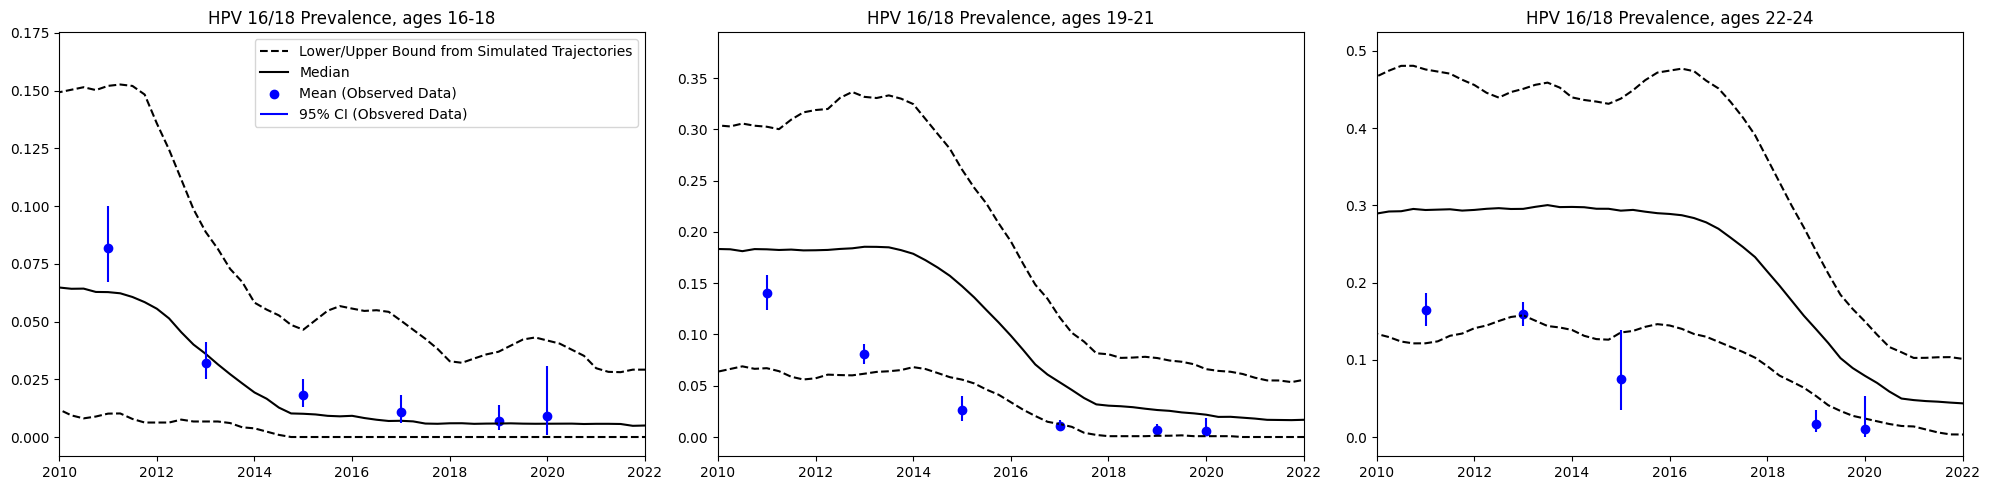

In [187]:
#HPV16/18 
fig, axs = plt.subplots(1,3, figsize=(20,5))

#Plot what we generated for 16-18
for i in range(age1618_prevs.shape[0]):
    axs[0].plot(xs, age1618_prevs[i,:], color='gray', linewidth=1, alpha=0)
axs[0].plot(xs,np.min(age1618_prevs, axis=0), color='black', linestyle='dashed', label='Lower/Upper Bound from Simulated Trajectories')
axs[0].plot(xs,np.median(age1618_prevs, axis=0), color='black', label='Median')
axs[0].plot(xs,np.max(age1618_prevs, axis=0), color='black', linestyle='dashed')
axs[0].set_xlim((2010,2022))
#Plot real-world data for 16-18
axs[0].scatter([2011,2013,2015,2017,2019, 2020],
               [0.082,0.032,0.018,0.011,0.007, 0.009], color='blue', label='Mean (Observed Data)')
axs[0].vlines(2011, 0.067, 0.1, color='blue', label='95% CI (Obsvered Data)')
axs[0].vlines(2013, 0.025, 0.041, color='blue')
axs[0].vlines(2015, 0.013, 0.025, color='blue')
axs[0].vlines(2017, 0.006, 0.018, color='blue')
axs[0].vlines(2019, 0.003, 0.014, color='blue')
axs[0].vlines(2020, 0.001, 0.0307, color='blue')
axs[0].set_title("HPV 16/18 Prevalence, ages 16-18")

#Plot what we generated for 19-21
for i in range(age1921_prevs.shape[0]):
    axs[1].plot(xs, age1921_prevs[i,:], color='gray', linewidth=1, alpha=0)
axs[1].plot(xs,np.min(age1921_prevs, axis=0), color='black', linestyle='dashed')
axs[1].plot(xs,np.median(age1921_prevs, axis=0), color='black')
axs[1].plot(xs,np.max(age1921_prevs, axis=0), color='black', linestyle='dashed')
axs[1].set_xlim((2010,2022))
#Plot real-world data for 19-21
axs[1].scatter([2011,2013,2015,2017,2019,2020],
               [0.14,0.081,0.026,0.011,0.007,0.006], color='blue')
axs[1].vlines(2011, 0.124, 0.158, color='blue')
axs[1].vlines(2013, 0.071, 0.091, color='blue')
axs[1].vlines(2015, 0.016, 0.04, color='blue')
axs[1].vlines(2017, 0.006, 0.017, color='blue')
axs[1].vlines(2019, 0.004, 0.013, color='blue')
axs[1].vlines(2020, 0.001, 0.019, color='blue')
axs[1].set_title("HPV 16/18 Prevalence, ages 19-21")

#Plot what we generated for 22-24
for i in range(age2224_prevs.shape[0]):
    axs[2].plot(xs, age2224_prevs[i,:], color='gray', linewidth=1, alpha=0)
axs[2].plot(xs,np.min(age2224_prevs, axis=0), color='black', linestyle='dashed')
axs[2].plot(xs,np.median(age2224_prevs, axis=0), color='black')
axs[2].plot(xs,np.max(age2224_prevs, axis=0), color='black', linestyle='dashed')
axs[2].set_xlim((2010,2022))
#Plot real-world data for 22-24
axs[2].scatter([2011,2013,2015,2019,2020],
               [0.164,0.159,0.075,0.017, 0.01], color='blue')
axs[2].vlines(2011, 0.144, 0.186, color='blue')
axs[2].vlines(2013, 0.144, 0.175, color='blue')
axs[2].vlines(2015, 0.035, 0.138, color='blue')
axs[2].vlines(2019, 0.007, 0.035, color='blue')
axs[2].vlines(2020, 0, 0.053, color='blue')
axs[2].set_title("HPV 16/18 Prevalence, ages 22-24")

axs[0].legend()
plt.tight_layout()

In [249]:
tracker = HPVPrevalenceTracker(
    snapshot_years=[2010, 2030, 2050],
    age_bins=np.arange(0, 101, 5)
)
tracker_vaccpop = HPVPrevalenceTracker(
    snapshot_years=[2010, 2030, 2050],
    age_bins=np.arange(0, 101, 5),
    vacc_pop_only=True
)
tracker_unvaccpop = HPVPrevalenceTracker(
    snapshot_years=[2010, 2030, 2050],
    age_bins=np.arange(0, 101, 5),
    unvacc_pop_only=True
)

test_sim = hpv.Sim(base_parss[-1], 
                   interventions=vaccinations + [tracker,
                                                            tracker_vaccpop,
                                                            tracker_unvaccpop
                                                        ])
test_sim['rand_seed'] = 0
test_sim['n_agents'] = 5_000
test_sim['end'] = 2050
test_sim['verbose']=1


print(test_sim['genotypes'])
test_sim.run()

ts =  [
    x for x in test_sim['interventions']
    if isinstance(x, HPVPrevalenceTracker)
]

tracker = ts[0]
tracker_vaccpop = ts[1]
tracker_unvaccpop = ts[2]





Loading location-specific demographic data for "united kingdom"
['hpv16', 'hpv18', 'hi5', 'ohr']
  Resetting parameter 'dur_precin' from {'dist': 'lognormal', 'par1': 3, 'par2': 9} to {'dist': 'lognormal', 'par1': 3, 'par2': 9} for genotype hpv16
  Resetting parameter 'cin_fn' from {'form': 'logf2', 'k': 0.3, 'x_infl': 0, 'ttc': 50} to {'form': 'logf2', 'k': 0.6437997355329332, 'x_infl': 0, 'ttc': 50} for genotype hpv16
  Resetting parameter 'dur_cin' from {'dist': 'lognormal', 'par1': 5, 'par2': 20} to {'dist': 'lognormal', 'par1': 5.022460538707652, 'par2': 20} for genotype hpv16
  Resetting parameter 'cancer_fn' from {'method': 'cin_integral', 'transform_prob': 0.002} to {'method': 'cin_integral', 'transform_prob': 0.002} for genotype hpv16
  Resetting parameter 'rel_beta' from 1.0 to 1.0 for genotype hpv16
  Resetting parameter 'sero_prob' from 0.75 to 0.75 for genotype hpv16
  Resetting parameter 'dur_precin' from {'dist': 'lognormal', 'par1': 2.5, 'par2': 9} to {'dist': 'lognorma

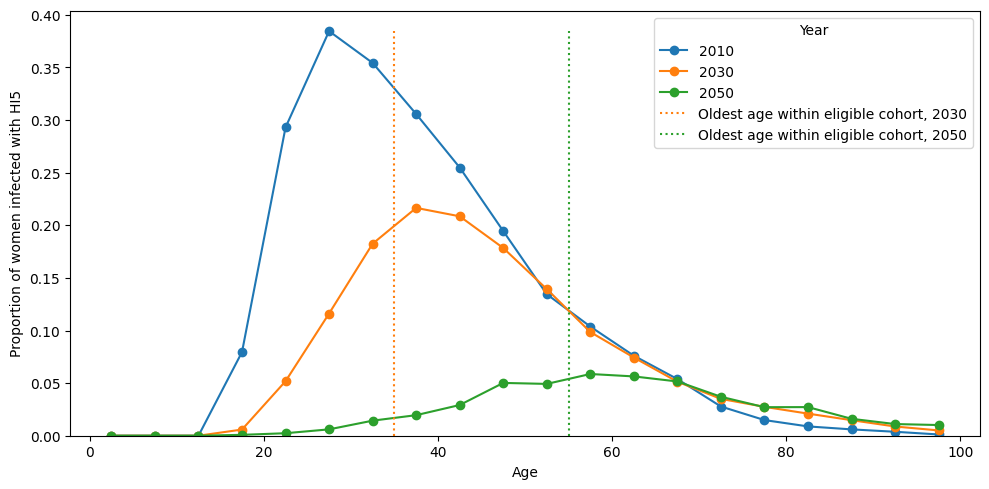

In [252]:
#t = tracker #full pop
#t = tracker_vaccpop #vacc pop
t = traker_unvaccpop #unvacc pop

time, p_any, p_16, p_18, p_1618,p_hi5,p_ohr, s_any, s_16, s_18, s_1618,s_hi5, s_ohr = t.get_results()



#s = s_any
#s = s_16
#s = s_18
s = s_1618
#s = s_hi5
#s = s_ohr


plt.figure(figsize=(10, 5))
age_mid = (tracker.age_bins[:-1] + tracker.age_bins[1:]) / 2
max_y = 0

for year, prev in s.items():
    max_y = max(max_y, max(prev))
    plt.plot(
        age_mid,
        prev,
        marker="o",
        label=str(year)
    )
plt.vlines(35, 0, max_y, colors='tab:orange', linestyles='dotted', label='Oldest age within eligible cohort, 2030')
plt.vlines(55, 0, max_y, colors='tab:green', linestyles='dotted', label='Oldest age within eligible cohort, 2050')

plt.xlabel("Age")
plt.ylabel("Proportion of women infected with HI5")
plt.ylim(bottom=0)
plt.legend(title="Year")


plt.tight_layout()
plt.show()

In [ ]:
tracker = HPVPrevalenceTracker(
    snapshot_years=[2010, 2030, 2050],
    age_bins=np.arange(0, 101, 5)
)
tracker_vaccpop = HPVPrevalenceTracker(
    snapshot_years=[2010, 2030, 2050],
    age_bins=np.arange(0, 101, 5),
    vacc_pop_only=True
)
tracker_unvaccpop = HPVPrevalenceTracker(
    snapshot_years=[2010, 2030, 2050],
    age_bins=np.arange(0, 101, 5),
    unvacc_pop_only=True
)

test_sim = hpv.Sim(#base_parss[0], 
    genotypes=base_parss[0]['genotypes'],
                   interventions=vaccinations + [tracker,
                                                            tracker_vaccpop,
                                                            tracker_unvaccpop
                                                        ])
test_sim['rand_seed'] = 0
test_sim['n_agents'] = 200_000
test_sim['end'] = 2050
test_sim['verbose']=1


print(test_sim['genotypes'])
test_sim.run()

ts =  [
    x for x in test_sim['interventions']
    if isinstance(x, HPVPrevalenceTracker)
]

tracker = ts[0]
tracker_vaccpop = ts[1]
tracker_unvaccpop = ts[2]





Loading location-specific demographic data for "nigeria"
['hpv16', 'hpv18', 'hi5', 'ohr']
Initializing sim with 200000 agents
Loading location-specific data for "nigeria"
  Running 1995.0 ( 0/224) (0.19 s)  ———————————————————— 0%
  Running 1995.2 ( 1/224) (0.30 s)  ———————————————————— 1%
  Running 1995.5 ( 2/224) (0.38 s)  ———————————————————— 1%
  Running 1995.8 ( 3/224) (0.43 s)  ———————————————————— 2%
  Running 1996.0 ( 4/224) (0.57 s)  ———————————————————— 2%
  Running 1996.2 ( 5/224) (0.66 s)  ———————————————————— 3%
  Running 1996.5 ( 6/224) (0.71 s)  ———————————————————— 3%
  Running 1996.8 ( 7/224) (0.77 s)  ———————————————————— 4%
  Running 1997.0 ( 8/224) (0.93 s)  ———————————————————— 4%
  Running 1997.2 ( 9/224) (1.06 s)  ———————————————————— 4%
  Running 1997.5 (10/224) (1.12 s)  ———————————————————— 5%
  Running 1997.8 (11/224) (1.19 s)  •——————————————————— 5%
  Running 1998.0 (12/224) (1.34 s)  •——————————————————— 6%
  Running 1998.2 (13/224) (1.44 s)  •————————————

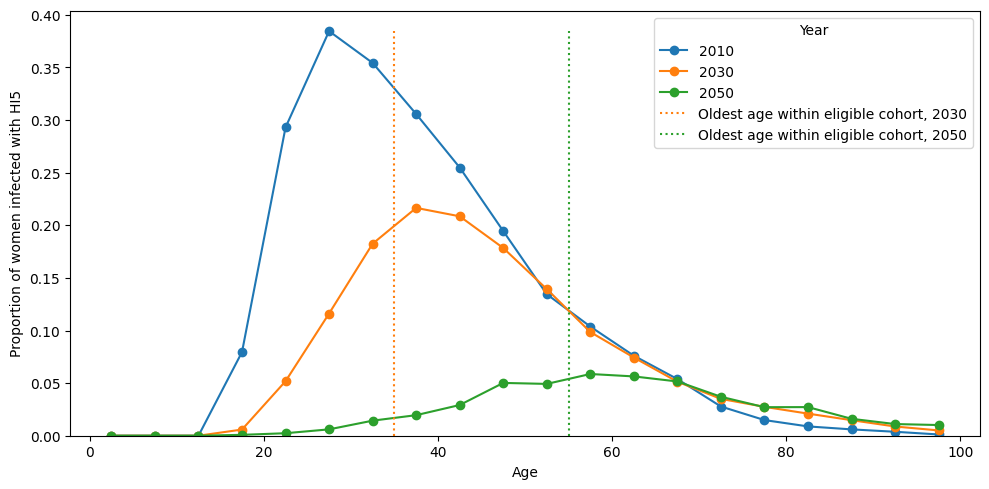

In [ ]:
t = tracker #full pop
#t = tracker_vaccpop #vacc pop
#t = traker_unvaccpop #unvacc pop

time, p_any, p_16, p_18, p_1618,p_hi5,p_ohr, s_any, s_16, s_18, s_1618,s_hi5, s_ohr = t.get_results()



#s = s_any
#s = s_16
#s = s_18
#s = s_1618
s = s_hi5
#s = s_ohr


plt.figure(figsize=(10, 5))
age_mid = (tracker.age_bins[:-1] + tracker.age_bins[1:]) / 2
max_y = 0

for year, prev in s.items():
    max_y = max(max_y, max(prev))
    plt.plot(
        age_mid,
        prev,
        marker="o",
        label=str(year)
    )
plt.vlines(35, 0, max_y, colors='tab:orange', linestyles='dotted', label='Oldest age within eligible cohort, 2030')
plt.vlines(55, 0, max_y, colors='tab:green', linestyles='dotted', label='Oldest age within eligible cohort, 2050')

plt.xlabel("Age")
plt.ylabel("Proportion of women infected with HI5")
plt.ylim(bottom=0)
plt.legend(title="Year")


plt.tight_layout()
plt.show()